In [ ]:
# CELL 1: Mount Drive and verify all inputs exist

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── All paths we will need in this notebook ────────────────────────
STGCN_CKPT       = '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30/best_stgcn_hri30.pt'
CTRGCN_CKPT      = '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30/best_ctrgcn_hri30.pt'

STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/ctrgcn_format/HRI30_CS.npz'

OUTPUT_DIR       = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Verification ───────────────────────────────────────────────────
all_ok = True
checks = [
    ("ST-GCN checkpoint",   STGCN_CKPT),
    ("CTR-GCN checkpoint",  CTRGCN_CKPT),
    ("ST-GCN test data",    STGCN_TEST_DATA),
    ("ST-GCN test labels",  STGCN_TEST_LABEL),
    ("CTR-GCN npz",         CTRGCN_TEST_NPZ),
]
print("\n--- File verification ---")
for name, path in checks:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f"  OK  {name}: {size_mb:.1f} MB")
    else:
        print(f"  MISSING  {name}: {path}")
        all_ok = False

if all_ok:
    print("\n[PASS] All inputs found. Proceed to Cell 2.")
else:
    print("\n[STOP] Fix missing files before continuing.")

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

--- File verification ---
  OK  ST-GCN checkpoint: 11.9 MB
  OK  CTR-GCN checkpoint: 5.8 MB
  OK  ST-GCN test data: 25.2 MB
  OK  ST-GCN test labels: 0.0 MB
  OK  CTR-GCN npz: 126.2 MB

[PASS] All inputs found. Proceed to Cell 2.


In [ ]:
# CELL 2: Clone repos, patch, and load both models

import os
import sys
import torch
import torch.nn as nn
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

STGCN_DIR  = '/content/st-gcn'
CTRGCN_DIR = '/content/CTR-GCN'

# ── ST-GCN ─────────────────────────────────────────────────────────
if not os.path.exists(STGCN_DIR):
    os.system(f'git clone https://github.com/yysijie/st-gcn.git {STGCN_DIR}')
    print("ST-GCN cloned.")
else:
    print("ST-GCN already present.")

stgcn_io = Path(f'{STGCN_DIR}/torchlight/torchlight/io.py')
text = stgcn_io.read_text()
if 'weights_only=False' not in text:
    text = text.replace(
        'torch.load(weights_path)',
        'torch.load(weights_path, weights_only=False, map_location="cpu")'
    )
    stgcn_io.write_text(text)
    print("ST-GCN torch.load patch applied.")

os.system(f'pip install -e {STGCN_DIR}/torchlight -q')

# ── CTR-GCN ────────────────────────────────────────────────────────
if not os.path.exists(CTRGCN_DIR):
    os.system(f'git clone https://github.com/Uason-Chen/CTR-GCN.git {CTRGCN_DIR}')
    print("CTR-GCN cloned.")
else:
    print("CTR-GCN already present.")

os.system('pip install -q tensorboardX torchpack fvcore iopath yacs thop')
os.system(f'pip install -e {CTRGCN_DIR}/torchlight -q')

ctrgcn_util = Path(f'{CTRGCN_DIR}/torchlight/torchlight/util.py')
text = ctrgcn_util.read_text()
if 'PaviLogger = None' not in text:
    text = text.replace(
        'from torchpack.runner.hooks import PaviLogger',
        'try:\n    from torchpack.runner.hooks import PaviLogger\nexcept ImportError:\n    PaviLogger = None'
    )
    ctrgcn_util.write_text(text)
    print("CTR-GCN torchpack patch applied.")

print("\nLoading model architectures...")

# ── ST-GCN model ───────────────────────────────────────────────────
sys.path.insert(0, STGCN_DIR)
from net.st_gcn import Model as STGCN_Model

stgcn_model = STGCN_Model(
    in_channels=3,
    num_class=30,
    dropout=0.5,
    edge_importance_weighting=True,
    graph_args={'layout': 'ntu-rgb+d', 'strategy': 'spatial'}
)

stgcn_ckpt = torch.load(
    '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30/best_stgcn_hri30.pt',
    map_location='cpu', weights_only=False
)
stgcn_state = stgcn_ckpt['model_state_dict'] if isinstance(stgcn_ckpt, dict) and 'model_state_dict' in stgcn_ckpt else stgcn_ckpt
stgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in stgcn_state.items()}
stgcn_model.load_state_dict(stgcn_state, strict=True)
stgcn_model = stgcn_model.to(device)
stgcn_model.eval()
print("ST-GCN loaded (30 classes) ✓")

# ── CTR-GCN model ──────────────────────────────────────────────────
sys.path.insert(0, CTRGCN_DIR)
from model.ctrgcn import Model as CTRGCN_Model

ctrgcn_model = CTRGCN_Model(
    num_class=30,
    num_point=25,
    num_person=1,
    graph='graph.ntu_rgb_d.Graph',
    graph_args={'labeling_mode': 'spatial'}
)

ctrgcn_ckpt = torch.load(
    '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30/best_ctrgcn_hri30.pt',
    map_location='cpu', weights_only=False
)
ctrgcn_state = ctrgcn_ckpt['model_state_dict'] if isinstance(ctrgcn_ckpt, dict) and 'model_state_dict' in ctrgcn_ckpt else ctrgcn_ckpt
ctrgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in ctrgcn_state.items()}
ctrgcn_model.load_state_dict(ctrgcn_state, strict=True)
ctrgcn_model = ctrgcn_model.to(device)
ctrgcn_model.eval()
print("CTR-GCN loaded (30 classes) ✓")

print("\n[PASS] Both models ready. Proceed to Cell 3.")

Using device: cuda
ST-GCN cloned.
ST-GCN torch.load patch applied.
CTR-GCN cloned.
CTR-GCN torchpack patch applied.

Loading model architectures...
ST-GCN loaded (30 classes) ✓
CTR-GCN loaded (30 classes) ✓

[PASS] Both models ready. Proceed to Cell 3.


In [ ]:
# CELL 3: Load test data for both models

import numpy as np
import pickle

STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/ctrgcn_format/HRI30_CS.npz'

# ── ST-GCN format ──────────────────────────────────────────────────
stgcn_test_data = np.load(STGCN_TEST_DATA)

with open(STGCN_TEST_LABEL, 'rb') as f:
    _, y_test = pickle.load(f)   # tuple: (sample_names, labels) — always unpack this way
stgcn_test_labels = np.array(y_test)

print(f"ST-GCN test data shape:   {stgcn_test_data.shape}")
print(f"ST-GCN test labels shape: {stgcn_test_labels.shape}")
print(f"ST-GCN label range:       {stgcn_test_labels.min()} to {stgcn_test_labels.max()}")

# ── CTR-GCN format ─────────────────────────────────────────────────
npz = np.load(CTRGCN_TEST_NPZ)
ctrgcn_test_data   = npz['x_test']
ctrgcn_test_labels = npz['y_test']

print(f"\nCTR-GCN test data shape:   {ctrgcn_test_data.shape}")
print(f"CTR-GCN test labels shape: {ctrgcn_test_labels.shape}")
print(f"CTR-GCN label range:       {ctrgcn_test_labels.min()} to {ctrgcn_test_labels.max()}")

# ── Cross-check ────────────────────────────────────────────────────
assert stgcn_test_data.shape[0] == ctrgcn_test_data.shape[0], (
    f"Sample mismatch: ST-GCN {stgcn_test_data.shape[0]} vs CTR-GCN {ctrgcn_test_data.shape[0]}"
)
assert (stgcn_test_labels == ctrgcn_test_labels).all(), (
    "Label mismatch between ST-GCN and CTR-GCN test sets!"
)

print(f"\n[PASS] {stgcn_test_data.shape[0]} test samples, 30 classes, labels match.")
print("Proceed to Cell 4.")

ST-GCN test data shape:   (588, 3, 150, 25, 1)
ST-GCN test labels shape: (588,)
ST-GCN label range:       0 to 29

CTR-GCN test data shape:   (588, 3, 150, 25, 1)
CTR-GCN test labels shape: (588,)
CTR-GCN label range:       0 to 29

[PASS] 588 test samples, 30 classes, labels match.
Proceed to Cell 4.


In [ ]:
# CELL 4: Occlusion simulation and Consensus Benchmark
import torch
import numpy as np
import csv
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------------------------------------------
# Core Functions
# ---------------------------------------------
def apply_occlusion(data_np, occlusion_rate, seed=None):
    if occlusion_rate == 0.0:
        return data_np.copy()
    if seed is not None:
        np.random.seed(seed)

    data_out = data_np.copy()
    num_joints = data_out.shape[3]
    num_to_zero = max(1, int(round(num_joints * occlusion_rate)))
    joints_to_zero = np.random.choice(num_joints, num_to_zero, replace=False)
    data_out[:, :, :, joints_to_zero, :] = 0.0
    return data_out

def get_model_logits(model, data_np, batch_size=64):
    model.eval()
    all_logits = []
    N = data_np.shape[0]
    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            batch = torch.tensor(data_np[start:end], dtype=torch.float32).to(device)
            output = model(batch)
            all_logits.append(output.cpu().numpy())
    return np.concatenate(all_logits)

def softmax(logits):
    exp_x = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-9), axis=1)

def consensus_fusion(logits_st, logits_ctr):
    probs_st = softmax(logits_st)
    probs_ctr = softmax(logits_ctr)

    H_st = entropy(probs_st)
    H_ctr = entropy(probs_ctr)

    W_st = np.exp(-H_st)
    W_ctr = np.exp(-H_ctr)

    sum_W = W_st + W_ctr
    W_st = W_st / sum_W
    W_ctr = W_ctr / sum_W

    probs_fused = W_st[:, None] * probs_st + W_ctr[:, None] * probs_ctr
    return np.argmax(probs_fused, axis=1)

# ---------------------------------------------
# PRE-FLIGHT DIAGNOSTIC
# ---------------------------------------------
print("============ DIAGNOSTIC START ============")
try:
    sample_st = stgcn_test_data[:4]
    sample_ctr = ctrgcn_test_data[:4]

    corr_st = apply_occlusion(sample_st, 0.50, seed=42)
    corr_ctr = apply_occlusion(sample_ctr, 0.50, seed=42)

    log_st = get_model_logits(stgcn_model, corr_st)
    log_ctr = get_model_logits(ctrgcn_model, corr_ctr)

    fused_preds = consensus_fusion(log_st, log_ctr)

    if fused_preds.shape != (4,):
        raise ValueError(f"Fusion broadcast failed! Expected shape (4,), got {fused_preds.shape}")

    print("[PASS] Entropy-weighted fusion mathematics perfectly aligned.")
    print("[SAFE] PROCEEDING WITH BENCHMARK LOOP...")
    print("==========================================\\n")
except Exception as e:
    raise RuntimeError(f"DIAGNOSTIC FAILED: {str(e)}")

# ---------------------------------------------
# Main Experiment Loop
# ---------------------------------------------
OCCLUSION_RATES = [0.0, 0.10, 0.20, 0.30, 0.50]
NUM_TRIALS = 5
results = []

print("PHASE 4 - CONSENSUS LAYER BENCHMARK")
print("===================================")

for rate in OCCLUSION_RATES:
    rate_label = f"{int(rate * 100)}%"
    n_trials = 1 if rate == 0.0 else NUM_TRIALS
    print(f"\\n--- Occlusion rate: {rate_label} ({n_trials} trial(s)) ---")

    st_accs = []
    ctr_accs = []
    con_accs = []

    for trial in range(n_trials):
        seed = 42 + trial

        st_corr = apply_occlusion(stgcn_test_data, rate, seed=seed)
        ctr_corr = apply_occlusion(ctrgcn_test_data, rate, seed=seed)

        logits_st = get_model_logits(stgcn_model, st_corr)
        logits_ctr = get_model_logits(ctrgcn_model, ctr_corr)

        st_preds = np.argmax(logits_st, axis=1)
        ctr_preds = np.argmax(logits_ctr, axis=1)
        con_preds = consensus_fusion(logits_st, logits_ctr)

        N = st_test_labels.shape[0] if 'st_test_labels' in locals() else stgcn_test_labels.shape[0]
        labels_np = stgcn_test_labels

        acc_st = 100.0 * (st_preds == labels_np).sum() / N
        acc_ctr = 100.0 * (ctr_preds == labels_np).sum() / N
        acc_con = 100.0 * (con_preds == labels_np).sum() / N

        st_accs.append(acc_st)
        ctr_accs.append(acc_ctr)
        con_accs.append(acc_con)

        print(f"  Trial {trial+1}: ST-GCN={acc_st:.1f}% | CTR-GCN={acc_ctr:.1f}% | CONSENSUS={acc_con:.1f}%")

    st_mean, st_std = float(np.mean(st_accs)), float(np.std(st_accs))
    ctr_mean, ctr_std = float(np.mean(ctr_accs)), float(np.std(ctr_accs))
    con_mean, con_std = float(np.mean(con_accs)), float(np.std(con_accs))

    print(f"  -> MEAN: ST={st_mean:.1f}% | CTR={ctr_mean:.1f}% | CON={con_mean:.1f}%")

    results.append({
        'occlusion_rate': rate_label,
        'st_trial_accs': st_accs, 'ctr_trial_accs': ctr_accs, 'con_trial_accs': con_accs,
        'st_mean': st_mean, 'st_std': st_std,
        'ctr_mean': ctr_mean, 'ctr_std': ctr_std,
        'con_mean': con_mean, 'con_std': con_std
    })

# ---------------------------------------------
# Save to CSV
# ---------------------------------------------
OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CSV_PATH = os.path.join(OUTPUT_DIR, 'consensus_benchmark_results.csv')

with open(CSV_PATH, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'occlusion_rate',
        'st_mean', 'st_std',
        'ctr_mean', 'ctr_std',
        'con_mean', 'con_std',
        'st_trials', 'ctr_trials', 'con_trials'
    ])
    for r in results:
        writer.writerow([
            r['occlusion_rate'],
            f"{r['st_mean']:.4f}", f"{r['st_std']:.4f}",
            f"{r['ctr_mean']:.4f}", f"{r['ctr_std']:.4f}",
            f"{r['con_mean']:.4f}", f"{r['con_std']:.4f}",
            r['st_trial_accs'], r['ctr_trial_accs'], r['con_trial_accs']
        ])

print(f"\\n[SAVED] CSV saved to Drive: {CSV_PATH}")

============ DIAGNOSTIC START ============
[PASS] Entropy-weighted fusion mathematics perfectly aligned.
[SAFE] PROCEEDING WITH BENCHMARK LOOP...
==========================================\n
PHASE 4 - CONSENSUS LAYER BENCHMARK
\n--- Occlusion rate: 0% (1 trial(s)) ---
  Trial 1: ST-GCN=61.2% | CTR-GCN=69.0% | CONSENSUS=70.7%
  -> MEAN: ST=61.2% | CTR=69.0% | CON=70.7%
\n--- Occlusion rate: 10% (5 trial(s)) ---
  Trial 1: ST-GCN=57.0% | CTR-GCN=57.3% | CONSENSUS=62.2%
  Trial 2: ST-GCN=57.0% | CTR-GCN=52.6% | CONSENSUS=59.9%
  Trial 3: ST-GCN=49.1% | CTR-GCN=59.0% | CONSENSUS=60.0%
  Trial 4: ST-GCN=43.0% | CTR-GCN=52.7% | CONSENSUS=54.9%
  Trial 5: ST-GCN=39.1% | CTR-GCN=42.2% | CONSENSUS=49.1%
  -> MEAN: ST=49.0% | CTR=52.8% | CON=57.2%
\n--- Occlusion rate: 20% (5 trial(s)) ---
  Trial 1: ST-GCN=39.6% | CTR-GCN=32.8% | CONSENSUS=43.0%
  Trial 2: ST-GCN=50.9% | CTR-GCN=36.9% | CONSENSUS=52.2%
  Trial 3: ST-GCN=36.6% | CTR-GCN=45.9% | CONSENSUS=49.5%
  Trial 4: ST-GCN=40.8% | CTR-GCN=3

Reading benchmark data directly from Drive...


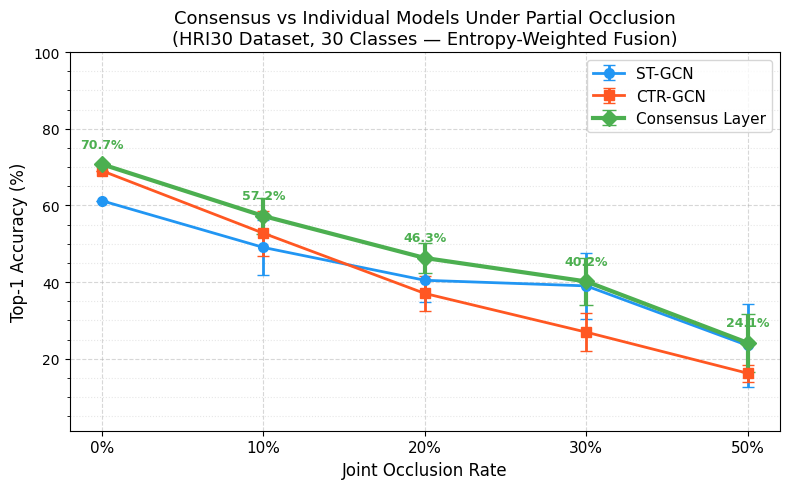


[SAVED] Plot successfully saved to Drive: /content/drive/MyDrive/HRC_Research/results/occlusion_benchmark/consensus_vs_individual.png


In [ ]:
# CELL 5: Plot Consensus vs Individual Models (Independent CSV Reader)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import os

# 1. Read data directly from your saved CSV in Google Drive
OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
CSV_PATH = os.path.join(OUTPUT_DIR, 'consensus_benchmark_results.csv')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Cannot find CSV at {CSV_PATH}. Make sure your Drive is mounted!")

print("Reading benchmark data directly from Drive...")
df = pd.read_csv(CSV_PATH)

# Extract data arrays
occlusion_labels = df['occlusion_rate'].tolist()
st_means = df['st_mean'].tolist()
ctr_means = df['ctr_mean'].tolist()
con_means = df['con_mean'].tolist()

st_stds = df['st_std'].tolist()
ctr_stds = df['ctr_std'].tolist()
con_stds = df['con_std'].tolist()

x = list(range(len(occlusion_labels)))

# 2. Build the Figure
fig, ax = plt.subplots(figsize=(8, 5))

# ST-GCN line (Blue)
ax.errorbar(x, st_means, yerr=st_stds, label='ST-GCN', marker='o', color='#2196F3', linewidth=2, markersize=7, capsize=4)

# CTR-GCN line (Orange)
ax.errorbar(x, ctr_means, yerr=ctr_stds, label='CTR-GCN', marker='s', color='#FF5722', linewidth=2, markersize=7, capsize=4)

# Consensus line (Green, Bold)
ax.errorbar(x, con_means, yerr=con_stds, label='Consensus Layer', marker='D', color='#4CAF50', linewidth=3, markersize=8, capsize=5)

# Annotate the Consensus points
for i, con in enumerate(con_means):
    ax.annotate(f'{con:.1f}%', xy=(i, con), xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9, color='#4CAF50', fontweight='bold')

# 3. Formatting
ax.set_xticks(x)
ax.set_xticklabels(occlusion_labels, fontsize=11)
ax.set_xlabel('Joint Occlusion Rate', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Consensus vs Individual Models Under Partial Occlusion\n(HRI30 Dataset, 30 Classes — Entropy-Weighted Fusion)', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

min_val = min(min(st_means), min(ctr_means), min(con_means))
ax.set_ylim(max(0, min_val - 15), 100)

plt.tight_layout()

# 4. Save to Drive
PLOT_PATH = os.path.join(OUTPUT_DIR, 'consensus_vs_individual.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[SAVED] Plot successfully saved to Drive: {PLOT_PATH}")

In [ ]:
# CELL 6: Final Summary Table (Independent CSV Reader)
import pandas as pd
import os

# 1. Read data directly from your saved CSV in Google Drive
OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
CSV_PATH = os.path.join(OUTPUT_DIR, 'consensus_benchmark_results.csv')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Cannot find CSV at {CSV_PATH}. Make sure your Drive is mounted!")

df = pd.read_csv(CSV_PATH)

# 2. Print a clean summary table to console
print("\n" + "=" * 75)
print("FINAL SUMMARY TABLE: CONSENSUS LAYER VS BASELINES")
print("=" * 75)
print(f"{'Occlusion':<12} | {'ST-GCN':>10} | {'CTR-GCN':>10} | {'Consensus':>11} | {'Improvement':>13}")
print("-" * 75)

for index, row in df.iterrows():
    occ = str(row['occlusion_rate'])
    st = float(row['st_mean'])
    ctr = float(row['ctr_mean'])
    con = float(row['con_mean'])

    # Calculate improvement over the BEST individual model at this occlusion level
    best_baseline = max(st, ctr)
    improvement = con - best_baseline

    print(f"{occ:<12} | {st:>9.2f}% | {ctr:>9.2f}% | {con:>10.2f}% | {improvement:>11.2f} pp")

print("=" * 75)


FINAL SUMMARY TABLE: CONSENSUS LAYER VS BASELINES
Occlusion    |     ST-GCN |    CTR-GCN |   Consensus |   Improvement
---------------------------------------------------------------------------
0%           |     61.22% |     69.05% |      70.75% |        1.70 pp
10%          |     49.05% |     52.76% |      57.24% |        4.49 pp
20%          |     40.48% |     37.04% |      46.29% |        5.82 pp
30%          |     39.01% |     26.94% |      40.17% |        1.16 pp
50%          |     23.47% |     16.22% |      24.15% |        0.68 pp
